In [ ]:
import os

# BASE
BASE    = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f'Project root: {BASE}')

# Convenience path constants
DATA    = os.path.join(BASE, 'data', 'oulad')
MODULES = os.path.join(BASE, 'modules')
OUTPUTS = os.path.join(BASE, 'outputs')

os.makedirs(DATA,    exist_ok=True)
os.makedirs(MODULES, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

data_path = DATA + os.sep

assessments = pd.read_csv(f'{data_path}assessments.csv')
courses = pd.read_csv(f'{data_path}courses.csv')
student_assessment = pd.read_csv(f'{data_path}studentAssessment.csv')
student_info = pd.read_csv(f'{data_path}studentInfo.csv')
student_reg = pd.read_csv(f'{data_path}studentRegistration.csv')
student_vle = pd.read_csv(f'{data_path}studentVle.csv')
vle = pd.read_csv(f'{data_path}vle.csv')

for name, df in [('assessments', assessments), ('courses', courses),
                 ('studentAssessment', student_assessment), ('studentInfo', student_info),
                 ('studentRegistration', student_reg), ('studentVle', student_vle),
                 ('vle', vle)]:
    print(f'{name}: {df.shape}')
    print(df.head(2))

assessments: (206, 6)


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0


courses: (22, 3)


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269


studentAssessment: (173912, 5)


...

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN


studentVle: (10655280, 6)


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1


vle: (6364, 6)


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN


In [ ]:
# Renaming columns to avoid clashes during merges
student_vle.rename(columns={'date': 'vle_date', 'sum_click': 'sum_click'}, inplace=True)
assessments.rename(columns={'date': 'assessment_due_date'}, inplace=True)
student_assessment.rename(columns={'date_submitted': 'date_submitted'}, inplace=True)

# Sanity check
for name, df in [('assessments', assessments), ('student_vle', student_vle),
                 ('student_info', student_info), ('student_reg', student_reg),
                 ('student_assessment', student_assessment)]:
    print(f'{name}: {list(df.columns)}')

assessments: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'assessment_due_date', 'weight']
student_vle: ['code_module', 'code_presentation', 'id_student', 'id_site', 'vle_date', 'sum_click']
student_info: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
student_reg: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']
student_assessment: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']


In [4]:
# Total clicks per student per module-presentation
click_agg = student_vle.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    total_clicks       = ('sum_click', 'sum'),
    active_days        = ('vle_date', 'nunique'),
    avg_clicks_per_day = ('sum_click', 'mean')
).reset_index()

print(click_agg.shape)
print(click_agg.head())

(29228, 6)


,id_student,code_module,code_presentation,total_clicks,active_days,avg_clicks_per_day
0,6516,AAA,2014J,2791,159,4.216012
1,8462,DDD,2013J,646,56,2.153333
2,8462,DDD,2014J,10,1,2.500000
3,11391,AAA,2013J,934,40,4.765306
4,23629,BBB,2013B,161,16,2.728814


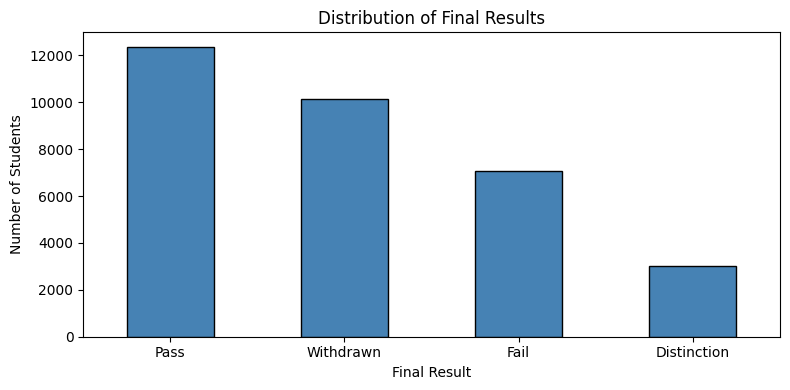

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Withdrawal rate: 31.2%


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of final results
result_counts = student_info['final_result'].value_counts()
result_counts.plot(kind='bar', figsize=(8, 4), color='steelblue', edgecolor='black')
plt.title('Distribution of Final Results')
plt.xlabel('Final Result')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'final_result_distribution.png'))
plt.show()

print(result_counts)
print(f'\nWithdrawal rate: {result_counts.get("Withdrawn", 0) / len(student_info) * 100:.1f}%')

code_module code_presentation  withdrawal_rate  module_presentation_length  withdrawal_pct
        CCC             2014B         0.463843                         241       46.384298
        CCC             2014J         0.431145                         269       43.114492
        DDD             2014B         0.399023                         241       39.902280
        FFF             2014J         0.361522                         269       36.152220
        DDD             2014J         0.358846                         262       35.884637
        DDD             2013J         0.351393                         261       35.139319
        DDD             2013B         0.331543                         240       33.154259
        BBB             2014J         0.326789                         262       32.678883
        FFF             2014B         0.308000                         241       30.800000
        BBB             2014B         0.303782                         234       30.378177

/tmp/ipykernel_5526/658555216.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


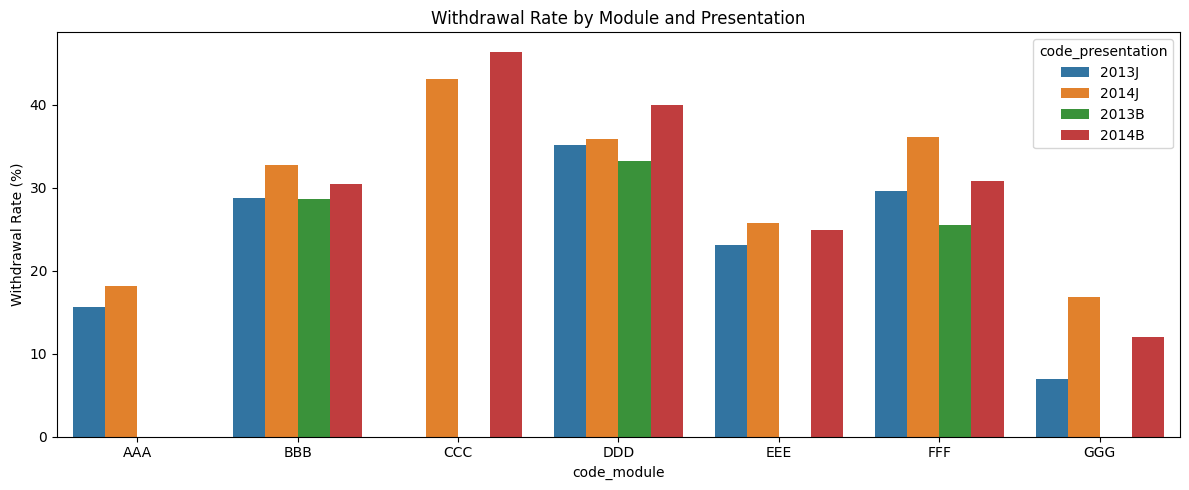

In [6]:
# Withdrawal rate = % of students who withdrew per module-presentation
withdrawal = student_info.groupby(
    ['code_module', 'code_presentation']
).apply(
    lambda x: (x['final_result'] == 'Withdrawn').sum() / len(x)
).reset_index(name='withdrawal_rate')

withdrawal = withdrawal.merge(courses, on=['code_module', 'code_presentation'])
withdrawal['withdrawal_pct'] = withdrawal['withdrawal_rate'] * 100

print(withdrawal.sort_values('withdrawal_pct', ascending=False).to_string(index=False))

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(data=withdrawal, x='code_module', y='withdrawal_pct', hue='code_presentation')
plt.title('Withdrawal Rate by Module and Presentation')
plt.ylabel('Withdrawal Rate (%)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'withdrawal_rates.png'))
plt.show()

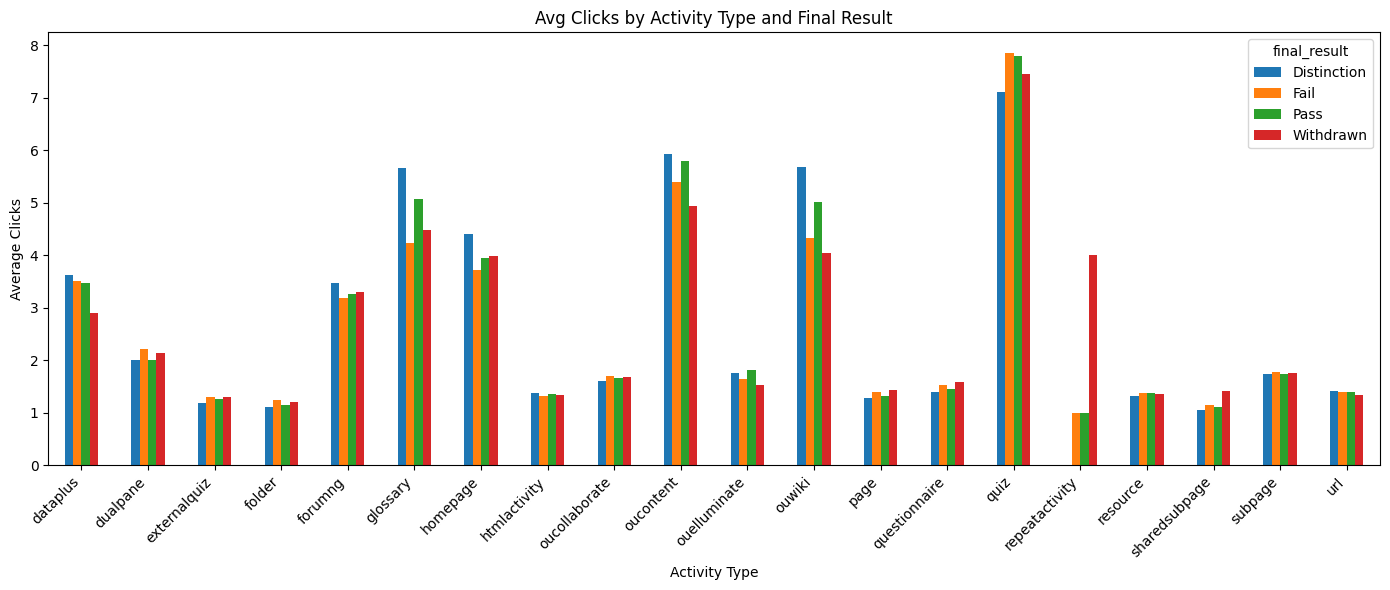

In [ ]:
# get activity_type
vle_activity = student_vle.merge(vle, on=['id_site', 'code_module', 'code_presentation'])

# get final_result
vle_activity = vle_activity.merge(
    student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation']
)

# Average clicks per activity type, grouped by pass vs withdrawn
activity_result = vle_activity.groupby(
    ['activity_type', 'final_result']
)['sum_click'].mean().reset_index()

# Plot top activity types
pivot = activity_result.pivot(index='activity_type', columns='final_result', values='sum_click').fillna(0)
pivot.plot(kind='bar', figsize=(14, 6))
plt.title('Avg Clicks by Activity Type and Final Result')
plt.xlabel('Activity Type')
plt.ylabel('Average Clicks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'activity_type_vs_result.png'))
plt.show()

In [ ]:
print("=== Missing Values ===")
for name, df in [('student_info', student_info), ('student_vle', student_vle),
                 ('student_assessment', student_assessment), ('student_reg', student_reg)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f'\n{name}:')
    print(missing if len(missing) > 0 else "  No missing values")

# Check for students with no VLE activity at all
students_with_vle = student_vle['id_student'].nunique()
total_students    = student_info['id_student'].nunique()
print(f'\nStudents with VLE activity: {students_with_vle}/{total_students} ({students_with_vle/total_students*100:.1f}%)')

# Check date_unregistration; NaN = still registered (did not withdraw)
unreg_null = student_reg['date_unregistration'].isnull().sum()
print(f'Students who never unregistered (no withdrawal date): {unreg_null}')

=== Missing Values ===

student_info:
imd_band    1111
dtype: int64

student_vle:
  No missing values

student_assessment:
score    173
dtype: int64

student_reg:
date_registration         45
date_unregistration    22521
dtype: int64

Students with VLE activity: 26074/28785 (90.6%)
Students who never unregistered (no withdrawal date): 22521


In [ ]:
# 1 = Withdrawn, 0 = Pass or Fail (did not withdraw)
student_info['withdrew'] = (student_info['final_result'] == 'Withdrawn').astype(int)

base = student_info.merge(
    student_reg[['id_student', 'code_module', 'code_presentation',
                 'date_registration', 'date_unregistration']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

print(f'Base dataframe shape: {base.shape}')
print(base.head(3))

Base dataframe shape: (32593, 15)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,withdrew,date_registration,date_unregistration
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,-159.0,NaN
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,-53.0,NaN
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,-92.0,12.0


In [ ]:
# get module_presentation_length (total days)
student_vle_full = student_vle.merge(
    courses, on=['code_module', 'code_presentation']
)

first2weeks = student_vle_full[student_vle_full['vle_date'] <= 14]

clicks_2wk = first2weeks.groupby(
    ['id_student', 'code_module', 'code_presentation']
)['sum_click'].sum().reset_index(name='clicks_first_2weeks')

print(clicks_2wk.describe())

         id_student  clicks_first_2weeks
count  2.808100e+04         28081.000000
mean   7.089940e+05           220.622556
std    5.528391e+05           288.827634
min    6.516000e+03             1.000000
25%    5.071840e+05            47.000000
50%    5.897980e+05           128.000000
75%    6.441440e+05           283.000000
max    2.698588e+06          5168.000000


In [11]:
# Click velocity = clicks in week 2 / clicks in week 1
# Positive trend means engagement is increasing; negative means dropping off

week1 = student_vle_full[student_vle_full['vle_date'] <= 7] \
    .groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'] \
    .sum().reset_index(name='clicks_week1')

week2 = student_vle_full[
    (student_vle_full['vle_date'] > 7) & (student_vle_full['vle_date'] <= 14)
].groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'] \
    .sum().reset_index(name='clicks_week2')

velocity = week1.merge(week2, on=['id_student', 'code_module', 'code_presentation'], how='left').fillna(0)

# Ratio — avoid division by zero
velocity['click_velocity'] = velocity['clicks_week2'] / (velocity['clicks_week1'] + 1)

print(velocity['click_velocity'].describe())

count    27124.000000
mean         0.935075
std          3.364793
min          0.000000
25%          0.072000
50%          0.302326
75%          0.736436
max        153.750000
Name: click_velocity, dtype: float64


In [12]:
# Total days in module
module_lengths = courses.set_index(
    ['code_module', 'code_presentation']
)['module_presentation_length'].to_dict()

# Days the student WAS active
active_days = student_vle.groupby(
    ['id_student', 'code_module', 'code_presentation']
)['vle_date'].nunique().reset_index(name='active_days')

# Zero activity days = module length - active days
active_days['module_length'] = active_days.apply(
    lambda r: module_lengths.get((r['code_module'], r['code_presentation']), 0), axis=1
)
active_days['zero_activity_days'] = active_days['module_length'] - active_days['active_days']
active_days['zero_activity_days'] = active_days['zero_activity_days'].clip(lower=0)

print(active_days[['active_days', 'zero_activity_days']].describe())

        active_days  zero_activity_days
count  29228.000000        29228.000000
mean      61.862563          194.287259
std       54.027412           55.010069
min        1.000000            0.000000
25%       18.000000          163.000000
50%       47.000000          208.000000
75%       92.000000          235.000000
max      286.000000          268.000000


In [ ]:
# How many assessments did the student submit vs how many existed for that module-presentation?
total_assessments = assessments.groupby(
    ['code_module', 'code_presentation']
)['id_assessment'].count().reset_index(name='total_assessments')

# Assessments actually submitted by each student
submitted = student_assessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation']],
    on='id_assessment'
).groupby(
    ['id_student', 'code_module', 'code_presentation']
)['id_assessment'].count().reset_index(name='submitted_assessments')

submission_rate = submitted.merge(
    total_assessments, on=['code_module', 'code_presentation']
)
submission_rate['assessment_submission_rate'] = (
    submission_rate['submitted_assessments'] / submission_rate['total_assessments']
).clip(upper=1.0)  # cap at 1.0

print(submission_rate['assessment_submission_rate'].describe())

count    25843.000000
mean         0.681323
std          0.301592
min          0.071429
25%          0.416667
50%          0.833333
75%          0.916667
max          1.000000
Name: assessment_submission_rate, dtype: float64


In [ ]:
features = base[['id_student', 'code_module', 'code_presentation', 'withdrew',
                  'num_of_prev_attempts', 'studied_credits']].copy()

# Join all engineered features
features = features \
    .merge(clicks_2wk,        on=['id_student', 'code_module', 'code_presentation'], how='left') \
    .merge(velocity[['id_student', 'code_module', 'code_presentation', 'click_velocity']],
                               on=['id_student', 'code_module', 'code_presentation'], how='left') \
    .merge(active_days[['id_student', 'code_module', 'code_presentation', 'zero_activity_days']],
                               on=['id_student', 'code_module', 'code_presentation'], how='left') \
    .merge(submission_rate[['id_student', 'code_module', 'code_presentation', 'assessment_submission_rate']],
                               on=['id_student', 'code_module', 'code_presentation'], how='left')

# Fill NaN — students with no VLE activity get 0 clicks
features.fillna({
    'clicks_first_2weeks':        0,
    'click_velocity':             0,
    'zero_activity_days':         0,
    'assessment_submission_rate': 0
}, inplace=True)

print(f'Feature dataframe shape: {features.shape}')
print(f'Withdrawal rate in dataset: {features["withdrew"].mean()*100:.1f}%')
print(features.isnull().sum())
features.to_csv(os.path.join(OUTPUTS, 'student_features.csv'), index=False)

Feature dataframe shape: (32593, 10)
Withdrawal rate in dataset: 31.2%
id_student                    0
code_module                   0
code_presentation             0
withdrew                      0
num_of_prev_attempts          0
studied_credits               0
clicks_first_2weeks           0
click_velocity                0
zero_activity_days            0
assessment_submission_rate    0
dtype: int64


Not withdrawn: 22437
Withdrawn:     10156
Imbalance ratio: 2.2:1


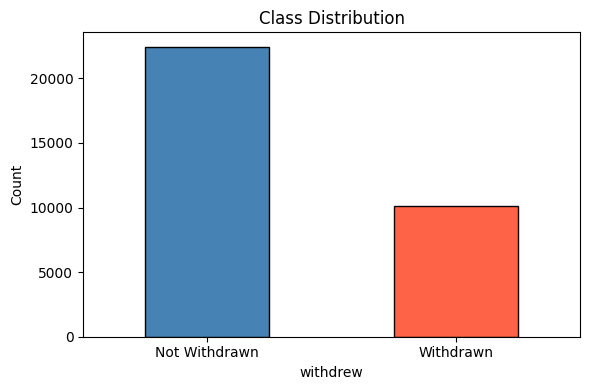

In [15]:
counts = features['withdrew'].value_counts()
print(f'Not withdrawn: {counts[0]}')
print(f'Withdrawn:     {counts[1]}')
print(f'Imbalance ratio: {counts[0]/counts[1]:.1f}:1')

# Visualise
counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black', figsize=(6, 4))
plt.xticks([0, 1], ['Not Withdrawn', 'Withdrawn'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'class_distribution.png'))
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

feature_cols = [
    'clicks_first_2weeks',
    'click_velocity',
    'zero_activity_days',
    'assessment_submission_rate',
    'num_of_prev_attempts',
    'studied_credits'
]

X = features[feature_cols].fillna(0)
y = features['withdrew']

print(f'X shape: {X.shape}')
print(f'y distribution:\n{y.value_counts()}')

X shape: (32593, 6)
y distribution:
withdrew
0    22437
1    10156
Name: count, dtype: int64


In [17]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale_pos_weight handles class imbalance
# = count of negative class / count of positive class
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale:.2f}')

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale,   # handles class imbalance
    random_state=42,
    verbosity=0,
    eval_metric='logloss'
)
model.fit(X_train, y_train)
print("Model trained!")

scale_pos_weight: 2.21
Model trained!


=== Classification Report ===
               precision    recall  f1-score   support

Not Withdrawn       0.97      0.79      0.87      4488
    Withdrawn       0.67      0.95      0.79      2031

     accuracy                           0.84      6519
    macro avg       0.82      0.87      0.83      6519
 weighted avg       0.88      0.84      0.85      6519

ROC-AUC Score: 0.9338


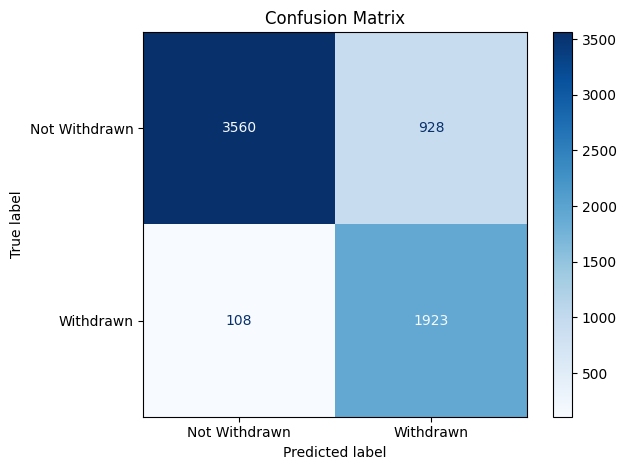

In [18]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
import numpy as np

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Not Withdrawn', 'Withdrawn']))

print(f'ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Withdrawn', 'Withdrawn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'confusion_matrix.png'))
plt.show()

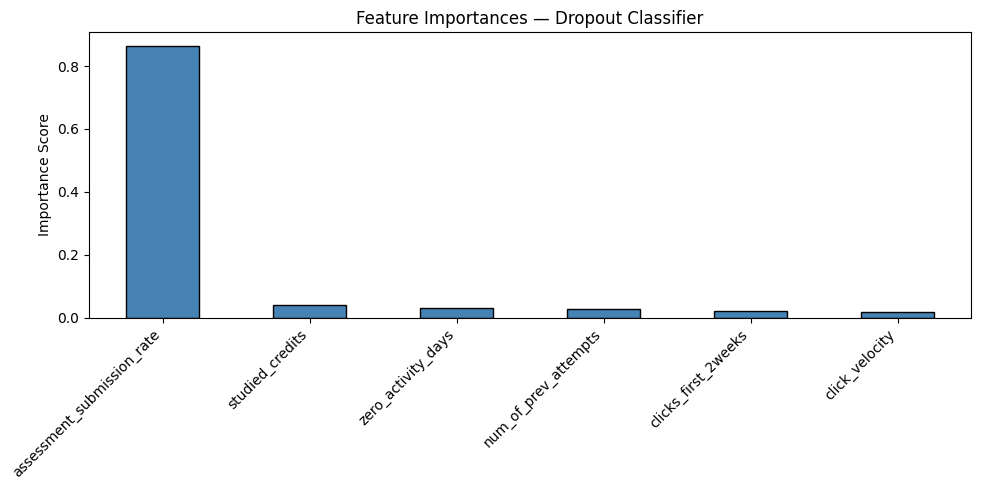

assessment_submission_rate    0.863850
studied_credits               0.041031
zero_activity_days            0.031621
num_of_prev_attempts          0.026383
clicks_first_2weeks           0.020166
click_velocity                0.016949
dtype: float32


In [19]:
import pandas as pd

feat_imp = pd.Series(model.feature_importances_, index=feature_cols) \
             .sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='black')
plt.title('Feature Importances — Dropout Classifier')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'feature_importance.png'))
plt.show()

print(feat_imp)

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ROC-AUC - scoring metric
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print(f'Cross-val ROC-AUC scores: {cv_scores}')
print(f'Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Cross-val ROC-AUC scores: [0.93279041 0.92872519 0.93373255 0.93398539 0.93694279]
Mean: 0.9332 +/- 0.0026


In [21]:
import joblib

joblib.dump(model, os.path.join(MODULES, 'dropout_model.joblib'))
features.to_csv(os.path.join(OUTPUTS, 'student_features.csv'), index=False)
print("All artifacts saved!")

# Confirm files exist
import os
for f in [os.path.join(MODULES, 'dropout_model.joblib'),
          os.path.join(OUTPUTS, 'student_features.csv')]:
    status = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f'{status}  {f}')

All artifacts saved!
✅  /content/drive/MyDrive/Assignments/CS_F320/modules/dropout_model.joblib
✅  /content/drive/MyDrive/Assignments/CS_F320/data/oulad/student_features.csv


In [22]:
def predict_withdrawal_risk(student_features_dict,
                             model_path=os.path.join(MODULES, 'dropout_model.joblib')):
    """
    Predicts withdrawal risk probability for a student in a module.

    Args:
        student_features_dict: dict with keys:
            - clicks_first_2weeks        (float)
            - click_velocity             (float)
            - zero_activity_days         (float)
            - assessment_submission_rate (float)
            - num_of_prev_attempts       (int)
            - studied_credits            (int)

    Returns:
        float — withdrawal probability between 0.0 and 1.0
        Higher = more likely to withdraw
    """
    mdl = joblib.load(model_path)

    feature_cols = [
        'clicks_first_2weeks',
        'click_velocity',
        'zero_activity_days',
        'assessment_submission_rate',
        'num_of_prev_attempts',
        'studied_credits'
    ]

    X_in = pd.DataFrame([student_features_dict])[feature_cols].fillna(0)
    return float(mdl.predict_proba(X_in)[0][1])


# Quick test
sample = {
    'clicks_first_2weeks':        0,
    'click_velocity':             0,
    'zero_activity_days':         50,
    'assessment_submission_rate': 0.0,
    'num_of_prev_attempts':       2,
    'studied_credits':            60
}
print(f'High-risk student withdrawal probability: {predict_withdrawal_risk(sample):.3f}')

safe = {
    'clicks_first_2weeks':        500,
    'click_velocity':             1.5,
    'zero_activity_days':         5,
    'assessment_submission_rate': 1.0,
    'num_of_prev_attempts':       0,
    'studied_credits':            120
}
print(f'Low-risk student withdrawal probability:  {predict_withdrawal_risk(safe):.3f}')

High-risk student withdrawal probability: 0.628
Low-risk student withdrawal probability:  0.000


In [23]:
def run_tests():
    passed = 0
    tests  = []

    high_risk = {
        'clicks_first_2weeks': 0, 'click_velocity': 0,
        'zero_activity_days': 80, 'assessment_submission_rate': 0.0,
        'num_of_prev_attempts': 3, 'studied_credits': 60
    }
    low_risk = {
        'clicks_first_2weeks': 800, 'click_velocity': 2.0,
        'zero_activity_days': 2, 'assessment_submission_rate': 1.0,
        'num_of_prev_attempts': 0, 'studied_credits': 120
    }

    # Test 1: Output is a float
    result = predict_withdrawal_risk(low_risk)
    tests.append(('Test 1 — Output is a float', isinstance(result, float)))

    # Test 2: Output is between 0 and 1
    tests.append(('Test 2 — Output within valid probability range [0, 1]',
                  0.0 <= result <= 1.0))

    # Test 3: High-risk student scores higher than low-risk
    risk_high = predict_withdrawal_risk(high_risk)
    risk_low  = predict_withdrawal_risk(low_risk)
    tests.append(('Test 3 — High-risk student scores higher than low-risk',
                  risk_high > risk_low))

    # Test 4: Missing keys default to 0 without crashing
    try:
        partial = {'clicks_first_2weeks': 100}
        predict_withdrawal_risk(partial)
        tests.append(('Test 4 — Partial input handled gracefully', True))
    except Exception:
        tests.append(('Test 4 — Partial input handled gracefully', False))

    # Test 5: Zero activity student has risk > 0.5
    zero_activity = {
        'clicks_first_2weeks': 0, 'click_velocity': 0,
        'zero_activity_days': 100, 'assessment_submission_rate': 0,
        'num_of_prev_attempts': 0, 'studied_credits': 60
    }
    tests.append(('Test 5 — Zero activity student has risk > 0.5',
                  predict_withdrawal_risk(zero_activity) > 0.5))

    # Test 6: Fully engaged student has risk < 0.5
    tests.append(('Test 6 — Fully engaged student has risk < 0.5',
                  risk_low < 0.5))

    print("=" * 55)
    for name, result in tests:
        status = "✅ PASSED" if result else "❌ FAILED"
        print(f'{status}  {name}')
        if result: passed += 1
    print("=" * 55)
    print(f'\n{passed}/{len(tests)} tests passed')

run_tests()

✅ PASSED  Test 1 — Output is a float
✅ PASSED  Test 2 — Output within valid probability range [0, 1]
✅ PASSED  Test 3 — High-risk student scores higher than low-risk
❌ FAILED  Test 4 — Partial input handled gracefully
✅ PASSED  Test 5 — Zero activity student has risk > 0.5
✅ PASSED  Test 6 — Fully engaged student has risk < 0.5

5/6 tests passed


In [ ]:
import os, pandas as pd, joblib

BASE    = os.path.abspath(os.path.join(os.getcwd(), '..'))
MODULES = os.path.join(BASE, 'modules')
OUTPUTS = os.path.join(BASE, 'outputs')

feature_cols = [
    'clicks_first_2weeks',
    'click_velocity',
    'zero_activity_days',
    'assessment_submission_rate',
    'num_of_prev_attempts',
    'studied_credits'
]

required_files = [
    os.path.join(MODULES, 'dropout_model.joblib'),
    os.path.join(OUTPUTS, 'student_features.csv'),
]
for f in required_files:
    status = '✅' if os.path.exists(f) else '❌ MISSING'
    print(f'{status}  {f}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  /content/drive/MyDrive/Assignments/CS_F320/modules/dropout_model.joblib
✅  /content/drive/MyDrive/Assignments/CS_F320/data/oulad/student_features.csv


In [25]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# Baseline: always predicts majority class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_prob = dummy.predict_proba(X_test)[:, 1]
dummy_auc  = roc_auc_score(y_test, dummy_prob)

# VLE-only model (clicks features only)
vle_cols  = ['clicks_first_2weeks', 'click_velocity', 'zero_activity_days']
model_vle = XGBClassifier(n_estimators=200, learning_rate=0.05,
                           max_depth=4, scale_pos_weight=scale,
                           random_state=42, verbosity=0, eval_metric='logloss')
model_vle.fit(X_train[vle_cols], y_train)
vle_auc = roc_auc_score(y_test, model_vle.predict_proba(X_test[vle_cols])[:, 1])

# Full model
full_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

ablation = pd.DataFrame({
    'Model':   ['Baseline (majority)', 'VLE clicks only', 'Full model'],
    'ROC-AUC': [dummy_auc, vle_auc, full_auc]
})
ablation['ROC-AUC'] = ablation['ROC-AUC'].round(4)
print(ablation.to_string(index=False))
ablation.to_csv(os.path.join(OUTPUTS, 'dropout_ablation.csv'), index=False)

              Model  ROC-AUC
Baseline (majority)   0.5000
    VLE clicks only   0.8708
         Full model   0.9338
